# 可选实验：逻辑回归与逻辑损失

在这个不计分的实验中，你将：
- 探索平方误差损失不适用于逻辑回归的原因
- 探索逻辑损失函数

In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from plt_logistic_loss import  plt_logistic_cost, plt_two_logistic_loss_curves, plt_simple_example
from plt_logistic_loss import soup_bowl, plt_logistic_squared_error
plt.style.use('./deeplearning.mplstyle')

## 逻辑回归也使用平方误差吗？
<img align="left" src="../work/images/C1_W3_SqErrorVsLogistic.png"     style=" width:400px; padding: 10px; " > 回顾一下，对于**线性**回归，我们使用了**平方误差代价函数**：
单变量平方误差代价公式为：
  $$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$

其中：
  $$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{2}$$

回想一下，平方误差代价有一个很好的性质：沿着代价的导数方向前进会到达最小值。

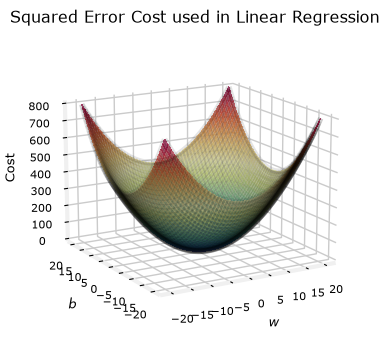

In [3]:
soup_bowl()

这个代价函数在线性回归中表现良好，因此自然会想到也将它用于逻辑回归。然而，正如上面的幻灯片所指出的，$f_{wb}(x)$ 现在包含非线性分量 sigmoid 函数：$f_{w,b}(x^{(i)}) = sigmoid(wx^{(i)} + b )$。让我们在先前实验的示例上尝试平方误差代价，并加入 sigmoid。

以下是我们的训练数据：

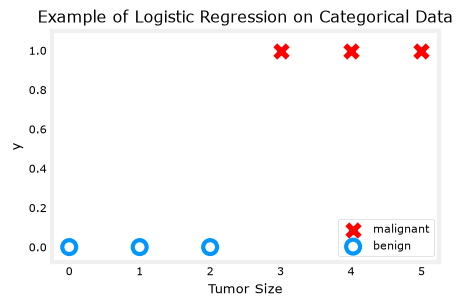

In [4]:
x_train = np.array([0., 1, 2, 3, 4, 5],dtype=np.longdouble)
y_train = np.array([0,  0, 0, 1, 1, 1],dtype=np.longdouble)
plt_simple_example(x_train, y_train)

现在，让我们使用*平方误差代价*绘制代价曲面图：
  $$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 $$ 
 
其中
  $$f_{w,b}(x^{(i)}) = sigmoid(wx^{(i)} + b )$$

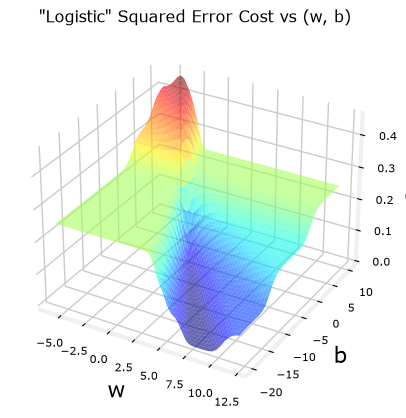

In [5]:
plt.close('all')
plt_logistic_squared_error(x_train,y_train)
plt.show()

虽然这会生成一个颇有意思的图，但上面的曲面远没有线性回归中的“汤碗”那么平滑！    

逻辑回归需要一个更适合其非线性性质的代价函数。这要从损失函数说起，下面将对此进行说明。

## 逻辑损失函数
<img align="left" src="../work/images/C1_W3_LogisticLoss_a.png"     style=" width:250px; padding: 2px; " >
<img align="left" src="../work/images/C1_W3_LogisticLoss_b.png"     style=" width:250px; padding: 2px; " >
<img align="left" src="../work/images/C1_W3_LogisticLoss_c.png"     style=" width:250px; padding: 2px; " >

逻辑回归使用一种更适合分类任务的损失函数，在这类任务中，目标值是 0 或 1，而不是任意数值。

>**定义说明：** 本课程使用以下定义：  
**损失**衡量单个样本与其目标值之间的差异，而  
**代价**衡量整个训练集上的损失


其定义如下：
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ 是单个数据点的代价，即：

\begin{equation}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = \begin{cases}
    - \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=1$}\\
    \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=0$}
  \end{cases}
\end{equation}


* $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ 是模型的预测值，而 $y^{(i)}$ 是目标值。

* $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot\mathbf{x}^{(i)}+b)$，其中函数 $g$ 是 sigmoid 函数。

该损失函数的决定性特征是使用两条不同的曲线：一条用于目标为零（$y=0$）的情况，另一条用于目标为一（$y=1$）的情况。合并后，这些曲线表现出损失函数所需的特性：预测与目标匹配时损失为零；预测与目标差异增大时，损失值迅速增加。请观察下面的曲线：

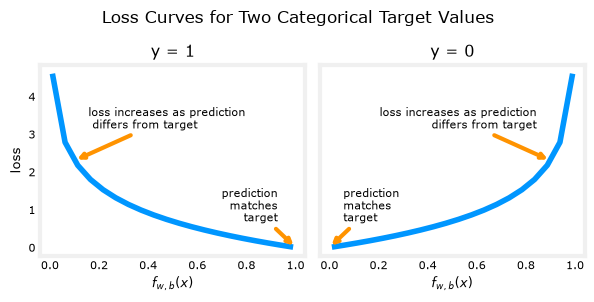

In [6]:
plt_two_logistic_loss_curves()

合并后，这些曲线与平方误差损失的二次曲线相似。请注意，x 轴是 $f_{\mathbf{w},b}$，即 sigmoid 的输出。sigmoid 输出严格位于 0 和 1 之间。

可以将上面的损失函数改写为更易实现的形式：
    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)$$
  
这个公式看起来相当复杂，但考虑到 $y^{(i)}$ 只能取 0 和 1 两个值，就没有那么可怕了。可以把公式分成两种情况：  
当 $ y^{(i)} = 0$ 时，左侧项被消去：
$$
\begin{align}
loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), 0) &= (-(0) \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - 0\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \\
&= -\log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)
\end{align}
$$
当 $ y^{(i)} = 1$ 时，右侧项被消去：
$$
\begin{align}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), 1) &=  (-(1) \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - 1\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\\
  &=  -\log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)
\end{align}
$$

有了这个新的逻辑回归损失函数，就可以构造一个包含所有样本损失的代价函数。这将是下一个实验的主题。现在，先看看上面简单示例中代价随参数变化的曲线：

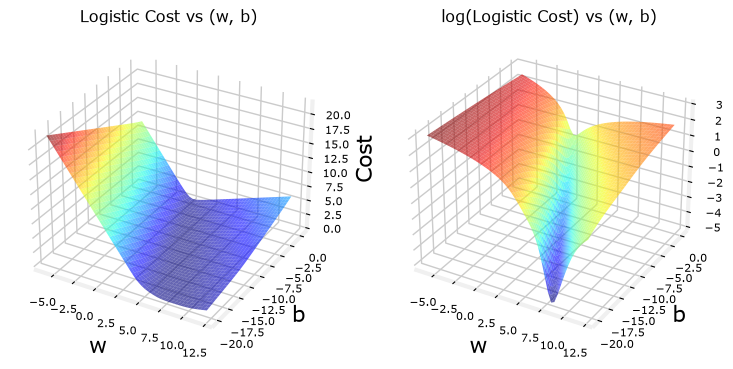

In [7]:
plt.close('all')
cst = plt_logistic_cost(x_train,y_train)

这条曲线非常适合梯度下降！它没有平台区、局部最小值或不连续点。请注意，它不像平方误差的情形那样呈碗状。这里同时绘制了代价及其对数，以说明即使代价很小时，曲线仍有斜率并会继续下降。提醒一下：你可以用鼠标旋转上面的图。

## 恭喜！  
你已经：
 - 确定平方误差损失函数不适合分类任务
 - 构造并研究了**适合**分类任务的逻辑损失函数。
